In [1]:
f = open("names.txt", "r")
words = f.read().split('\n')

In [2]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
import torch

In [4]:
N = torch.zeros((27,27), dtype=torch.int32)

In [5]:
chars = [chr(i) for i in range(ord('a'), ord('z') + 1)]
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [6]:

for w in words:
    chs = ['.'] + list(w) + ['.']
    for c1, c2 in zip(chs, chs[1:]):
        idx1 = stoi[c1]
        idx2 = stoi[c2]
        N[idx1, idx2] += 1


(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

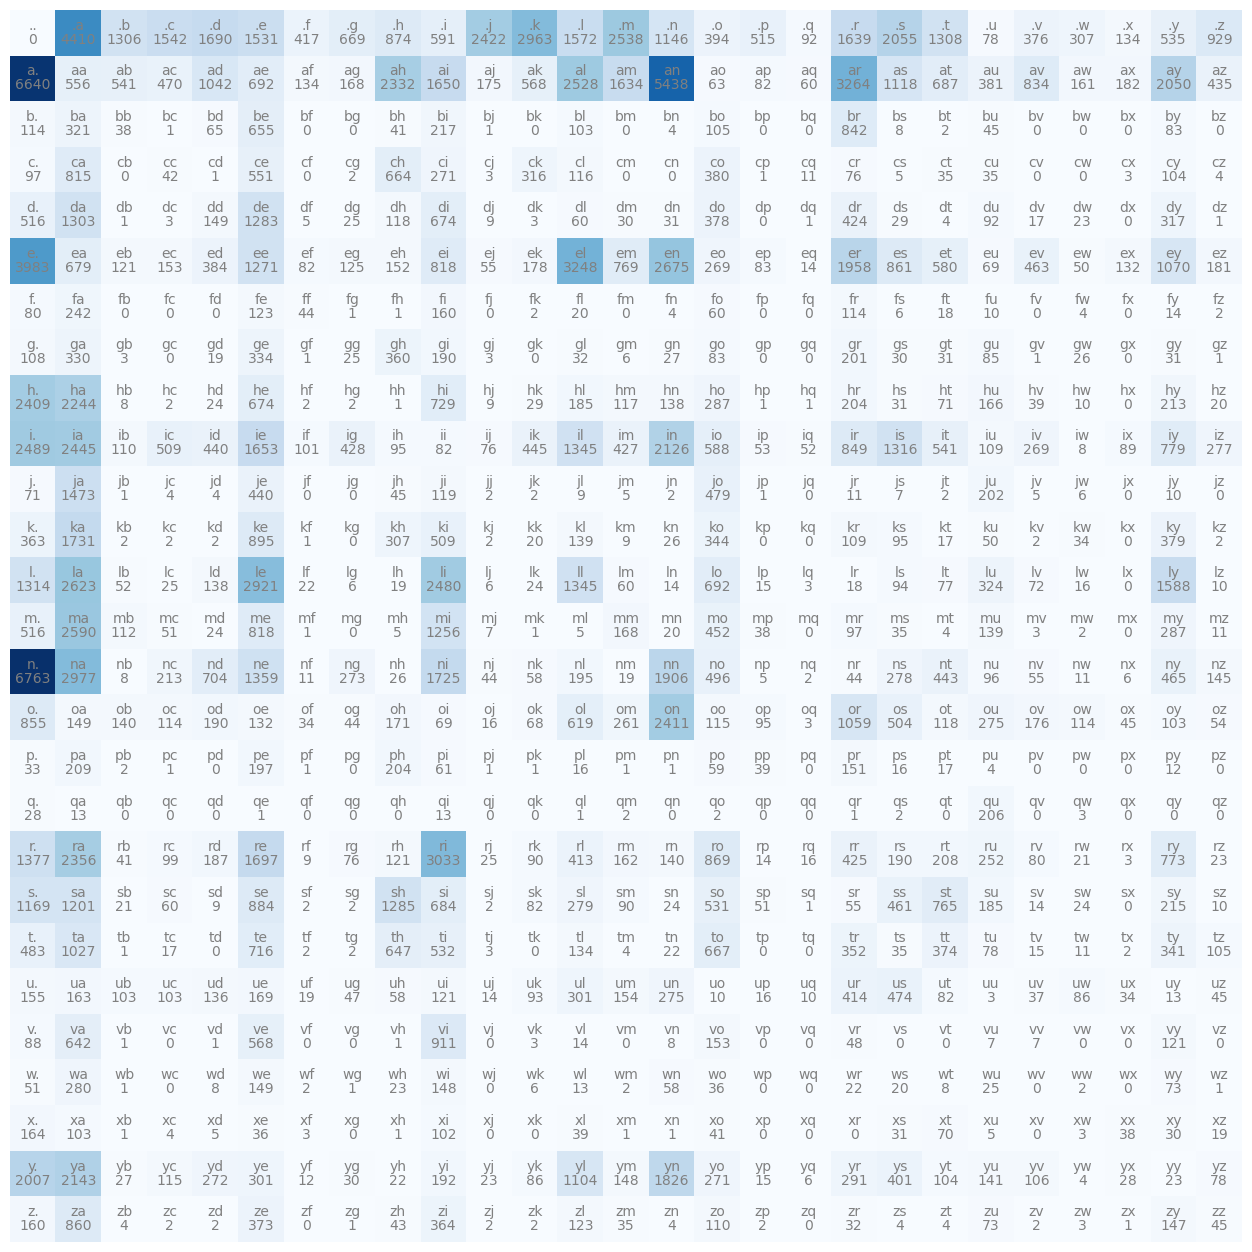

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color="gray")
plt.axis('off') 

In [8]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)

In [9]:
g = torch.Generator().manual_seed(2147483647)

In [10]:
for i in range(10):
    ix = 0
    out = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out += itos[ix]
        if ix == 0:
            break
    print(i + 1,''.join(out))

1 cexze.
2 momasurailezitynn.
3 konimittain.
4 llayn.
5 ka.
6 da.
7 staiyaubrtthrigotai.
8 moliellavo.
9 ke.
10 teda.


In [11]:
log_likelihood = 0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        prob = P[idx1,idx2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f"{ch1}{ch2}: {prob:.4f} log(prob): {logprob:.4f}")
print(f"Loss: {-log_likelihood/n:.4f}")

Loss: 2.4544


In [12]:
# create the training set of all the bi-gram
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs)
ys = torch.tensor(ys)
print(xs)
print(ys)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [23]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)


In [103]:

import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
counts = (xenc @ W).exp()
probs = counts / counts.sum(1, keepdim=True)

loss = -probs[torch.arange(5), ys].log().mean()
print(loss.item())

2.6686630249023438


In [26]:
W.grad = None
loss.backward()

In [102]:
W.data += -0.1 * W.grad

In [106]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    ix = 0
    prob = P[idx1,idx2]
    print(P)

tensor([[3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
         1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
         4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
         5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
         4.2109e-03, 1.6719e-02, 2.9008e-02],
        [1.9583e-01, 1.6425e-02, 1.5983e-02, 1.3889e-02, 3.0756e-02, 2.0435e-02,
         3.9809e-03, 4.9835e-03, 6.8796e-02, 4.8685e-02, 5.1899e-03, 1.6779e-02,
         7.4575e-02, 4.8213e-02, 1.6039e-01, 1.8872e-03, 2.4475e-03, 1.7988e-03,
         9.6279e-02, 3.2997e-02, 2.0288e-02, 1.1264e-02, 2.4623e-02, 4.7771e-03,
         5.3963e-03, 6.0480e-02, 1.2857e-02],
        [4.3039e-02, 1.2051e-01, 1.4596e-02, 7.4850e-04, 2.4701e-02, 2.4551e-01,
         3.7425e-04, 3.7425e-04, 1.5719e-02, 8.1587e-02, 7.4850e-04, 3.7425e-04,
         3.8922e-02, 3.7425e-04, 1.8713e-03, 3.9671e-02, 3.7425e-04, 3.7425e-04,
         3.1549e-